In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_data(train_path, val_path, test_path):
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)

    train_df = train_df.drop('Id', axis=1)
    val_df = val_df.drop('Id', axis=1)
    test_df = test_df.drop('Id', axis=1)

    for df in [train_df, val_df, test_df]:
        for col in df.columns:
            if df[col].dtype in ['int64', 'float64']:
                df[col].fillna(df[col].median(), inplace=True)

    X_train = train_df.drop('Class', axis=1).values
    y_train = train_df['Class'].values

    X_val = val_df.drop('Class', axis=1).values
    y_val = val_df['Class'].values

    X_test = test_df.drop('Class', axis=1).values
    y_test = test_df['Class'].values

    return X_train, y_train, X_val, y_val, X_test, y_test

def min_max_normalize(X_train, X_val, X_test):
    min_vals = X_train.min(axis=0)
    max_vals = X_train.max(axis=0)
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1

    X_train_norm = (X_train - min_vals) / range_vals
    X_val_norm = (X_val - min_vals) / range_vals
    X_test_norm = (X_test - min_vals) / range_vals

    return X_train_norm, X_val_norm, X_test_norm

X_train, y_train, X_val, y_val, X_test, y_test = load_data('/content/train.csv', '/content/validation.csv', '/content/test.csv')
X_train_norm, X_val_norm, X_test_norm = min_max_normalize(X_train, X_val, X_test)

<ipython-input-1-cd5de6ca27ab>:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, lambda_param=0.01, n_iterations=1000, batch_size=16):
        self.learning_rate = learning_rate
        self.lambda_param = lambda_param
        self.n_iterations = n_iterations
        self.batch_size = batch_size
        self.weights = None
        self.bias = None
        self.loss_history = []
        self.train_acc_history = []
        self.val_acc_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, y_true, y_pred):

        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

        if self.lambda_param > 0:
            loss += (self.lambda_param / 2) * np.sum(self.weights ** 2)
        return loss

    def compute_accuracy(self, y_true, y_pred):
        y_pred_class = [1 if p >= 0.5 else 0 for p in y_pred]
        return np.mean(y_pred_class == y_true)

    def fit(self, X_train, y_train, X_val=None, y_val=None, verbose=True):
        n_samples, n_features = X_train.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for iteration in range(self.n_iterations):
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]

            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]

                linear_model = np.dot(X_batch, self.weights) + self.bias
                y_pred = self.sigmoid(linear_model)

                dw = (1 / len(X_batch)) * np.dot(X_batch.T, (y_pred - y_batch))
                if self.lambda_param > 0:
                    dw += self.lambda_param * self.weights
                db = (1 / len(X_batch)) * np.sum(y_pred - y_batch)

                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

            train_pred = self.predict_proba(X_train)
            train_loss = self.compute_loss(y_train, train_pred)
            train_acc = self.compute_accuracy(y_train, train_pred)
            self.loss_history.append(train_loss)
            self.train_acc_history.append(train_acc)

            if X_val is not None and y_val is not None:
                val_pred = self.predict_proba(X_val)
                val_acc = self.compute_accuracy(y_val, val_pred)
                self.val_acc_history.append(val_acc)

            if verbose and iteration % 100 == 0:
                print(f"Iteration {iteration}: Train Loss = {train_loss:.4f}, Train Acc = {train_acc:.4f}", end="")
                if X_val is not None and y_val is not None:
                    print(f", Val Acc = {val_acc:.4f}")
                else:
                    print()

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_proba(X)
        return [1 if p >= threshold else 0 for p in probabilities]

    def evaluate(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)



In [ ]:
def experiment_learning_rates(X_train, y_train, X_val, y_val):
    learning_rates = [10000, 1000, 100, 10, 1, 0.1, 0.01, 0.001, 0.0001, 0.00001]
    iterations = [10, 100, 1000, 10000]

    train_results = np.zeros((len(learning_rates), len(iterations)))
    val_results = np.zeros((len(learning_rates), len(iterations)))

    for i, lr in enumerate(learning_rates):
        for j, n_iter in enumerate(iterations):
            try:
                model = LogisticRegression(learning_rate=lr, n_iterations=n_iter)
                model.fit(X_train, y_train, X_val, y_val, verbose=False)
                train_results[i, j] = model.train_acc_history[-1]
                val_results[i, j] = model.val_acc_history[-1] if model.val_acc_history else 0
                print(f"LR: {lr}, Iter: {n_iter}, Train Acc: {train_results[i, j]:.4f}, Val Acc: {val_results[i, j]:.4f}")
            except:
                print(f"Overflow occurred with LR: {lr}, Iter: {n_iter}")
                train_results[i, j] = np.nan
                val_results[i, j] = np.nan

    return train_results, val_results

In [32]:
def plot_learning_curves(model, title):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(model.train_acc_history, label='Train Accuracy')
    if model.val_acc_history:
        plt.plot(model.val_acc_history, label='Validation Accuracy')
    plt.xlabel('Iterations')
    plt.ylabel('Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(model.loss_history, label='Train Loss')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [33]:
def experiment_batch_sizes(X_train, y_train, X_val, y_val):
    batch_sizes = [4, 8, 16, 32, 64]
    val_accuracies = []
    for bs in batch_sizes:
        model = LogisticRegression(learning_rate=0.01, n_iterations=1000, batch_size=bs)
        model.fit(X_train, y_train, X_val, y_val, verbose=False)
        val_acc = model.evaluate(X_val, y_val)
        val_accuracies.append(val_acc)
        print(f"Batch Size: {bs}, Val Accuracy: {val_acc:.4f}")
    plt.figure()
    plt.plot(batch_sizes, val_accuracies, 'o-')
    plt.xlabel('Batch Size')
    plt.ylabel('Validation Accuracy')
    plt.title('Validation Accuracy vs Batch Size')
    plt.grid()
    plt.show()


In [34]:
def experiment_regularization(X_train, y_train, X_val, y_val):
    lambda_values = [0, 0.001, 0.01, 0.1, 1, 10]
    train_accuracies = []
    val_accuracies = []

    for l in lambda_values:
        model = LogisticRegression(learning_rate=0.01, lambda_param=l, n_iterations=1000)
        model.fit(X_train, y_train, X_val, y_val, verbose=False)
        train_acc = model.evaluate(X_train, y_train)
        val_acc = model.evaluate(X_val, y_val)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        print(f"Lambda: {l}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    plt.figure()
    plt.plot(lambda_values, train_accuracies, 'o-', label='Train Accuracy')
    plt.plot(lambda_values, val_accuracies, 'o-', label='Validation Accuracy')
    plt.xscale('log')
    plt.xlabel('Lambda (log scale)')
    plt.ylabel('Accuracy')
    plt.title('Effect of L2 Regularization')
    plt.legend()
    plt.grid()
    plt.show()


In [35]:
def min_max_normalize(X_train, X_val, X_test):
    min_vals = X_train.min(axis=0)
    max_vals = X_train.max(axis=0)
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1

    X_train_norm = (X_train - min_vals) / range_vals
    X_val_norm = (X_val - min_vals) / range_vals
    X_test_norm = (X_test - min_vals) / range_vals

    return X_train_norm, X_val_norm, X_test_norm

X_train_norm, X_val_norm, X_test_norm = min_max_normalize(X_train, X_val, X_test)




In [37]:
train_results, val_results = experiment_learning_rates(X_train_norm, y_train, X_val_norm, y_val)

<ipython-input-30-68e7f679b111>:14: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
<ipython-input-30-68e7f679b111>:23: RuntimeWarning: overflow encountered in square
  loss += (self.lambda_param / 2) * np.sum(self.weights ** 2)
<ipython-input-30-68e7f679b111>:52: RuntimeWarning: overflow encountered in multiply
  self.weights -= self.learning_rate * dw


LR: 10000, Iter: 10, Train Acc: 0.6544, Val Acc: 0.6571
LR: 10000, Iter: 100, Train Acc: 0.6544, Val Acc: 0.6571
LR: 10000, Iter: 1000, Train Acc: 0.6544, Val Acc: 0.6571
LR: 10000, Iter: 10000, Train Acc: 0.6544, Val Acc: 0.6571
LR: 1000, Iter: 10, Train Acc: 0.6544, Val Acc: 0.6571
LR: 1000, Iter: 100, Train Acc: 0.6544, Val Acc: 0.6571
LR: 1000, Iter: 1000, Train Acc: 0.6544, Val Acc: 0.6571
LR: 1000, Iter: 10000, Train Acc: 0.6544, Val Acc: 0.6571
LR: 100, Iter: 10, Train Acc: 0.6544, Val Acc: 0.6571
LR: 100, Iter: 100, Train Acc: 0.3456, Val Acc: 0.3429
LR: 100, Iter: 1000, Train Acc: 0.3456, Val Acc: 0.3429
LR: 100, Iter: 10000, Train Acc: 0.9018, Val Acc: 0.9214
LR: 10, Iter: 10, Train Acc: 0.9673, Val Acc: 0.9429
LR: 10, Iter: 100, Train Acc: 0.9305, Val Acc: 0.9571
LR: 10, Iter: 1000, Train Acc: 0.9448, Val Acc: 0.9500
LR: 10, Iter: 10000, Train Acc: 0.9346, Val Acc: 0.9500
LR: 1, Iter: 10, Train Acc: 0.9714, Val Acc: 0.9429
LR: 1, Iter: 100, Train Acc: 0.9714, Val Acc: 0.9429


=== Q2/Q3: Learning Curves ===
Iteration 0: Train Loss = 0.5180, Train Acc = 0.9714, Val Acc = 0.9571
Iteration 100: Train Loss = 0.1852, Train Acc = 0.9714, Val Acc = 0.9429
Iteration 200: Train Loss = 0.1852, Train Acc = 0.9714, Val Acc = 0.9429
Iteration 300: Train Loss = 0.1852, Train Acc = 0.9714, Val Acc = 0.9429
Iteration 400: Train Loss = 0.1852, Train Acc = 0.9714, Val Acc = 0.9429
Iteration 500: Train Loss = 0.1852, Train Acc = 0.9714, Val Acc = 0.9429
Iteration 600: Train Loss = 0.1852, Train Acc = 0.9714, Val Acc = 0.9429
Iteration 700: Train Loss = 0.1852, Train Acc = 0.9714, Val Acc = 0.9429
Iteration 800: Train Loss = 0.1852, Train Acc = 0.9714, Val Acc = 0.9429
Iteration 900: Train Loss = 0.1852, Train Acc = 0.9714, Val Acc = 0.9429


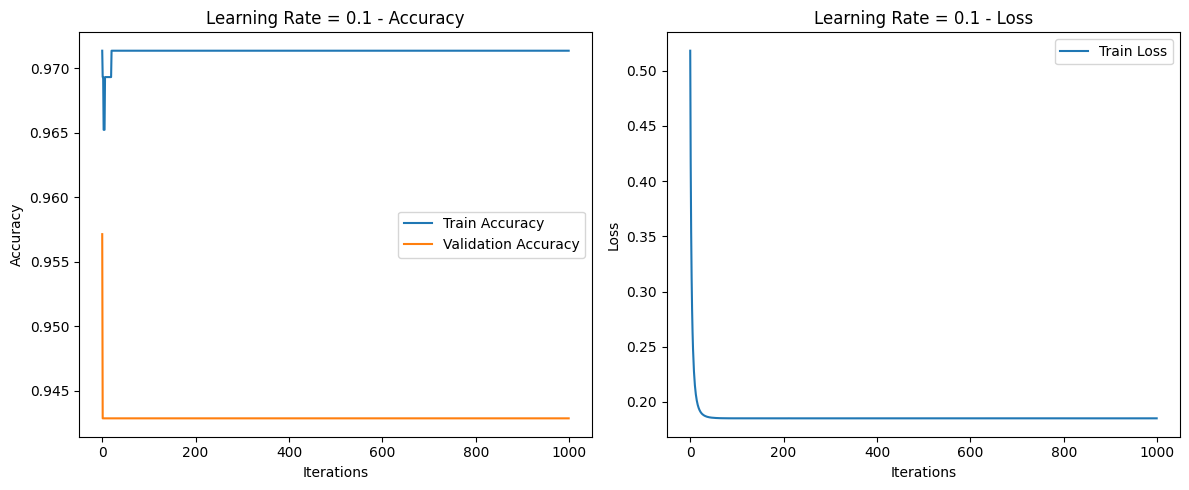

Iteration 0: Train Loss = 0.6908, Train Acc = 0.9775, Val Acc = 0.9571
Iteration 100: Train Loss = 0.5172, Train Acc = 0.9734, Val Acc = 0.9500
Iteration 200: Train Loss = 0.4165, Train Acc = 0.9734, Val Acc = 0.9429
Iteration 300: Train Loss = 0.3538, Train Acc = 0.9693, Val Acc = 0.9429
Iteration 400: Train Loss = 0.3124, Train Acc = 0.9693, Val Acc = 0.9429
Iteration 500: Train Loss = 0.2839, Train Acc = 0.9693, Val Acc = 0.9429
Iteration 600: Train Loss = 0.2634, Train Acc = 0.9693, Val Acc = 0.9429
Iteration 700: Train Loss = 0.2482, Train Acc = 0.9693, Val Acc = 0.9429
Iteration 800: Train Loss = 0.2367, Train Acc = 0.9693, Val Acc = 0.9429
Iteration 900: Train Loss = 0.2278, Train Acc = 0.9693, Val Acc = 0.9429


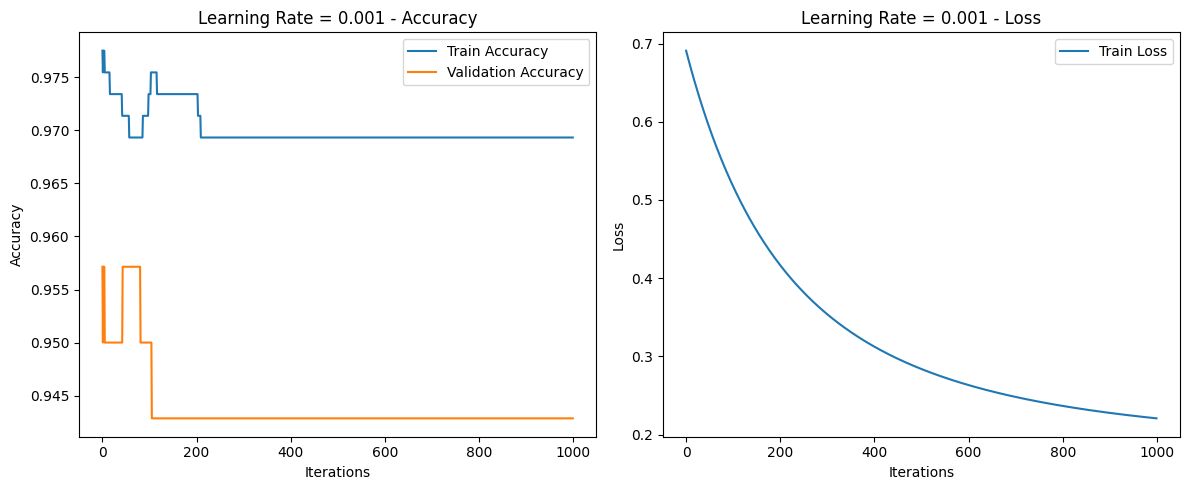

Iteration 0: Train Loss = 0.6931, Train Acc = 0.9755, Val Acc = 0.9500
Iteration 100: Train Loss = 0.6908, Train Acc = 0.9755, Val Acc = 0.9500
Iteration 200: Train Loss = 0.6885, Train Acc = 0.9755, Val Acc = 0.9500
Iteration 300: Train Loss = 0.6862, Train Acc = 0.9755, Val Acc = 0.9500
Iteration 400: Train Loss = 0.6839, Train Acc = 0.9755, Val Acc = 0.9500
Iteration 500: Train Loss = 0.6816, Train Acc = 0.9755, Val Acc = 0.9500
Iteration 600: Train Loss = 0.6794, Train Acc = 0.9755, Val Acc = 0.9500
Iteration 700: Train Loss = 0.6771, Train Acc = 0.9755, Val Acc = 0.9500
Iteration 800: Train Loss = 0.6749, Train Acc = 0.9755, Val Acc = 0.9500
Iteration 900: Train Loss = 0.6727, Train Acc = 0.9755, Val Acc = 0.9500


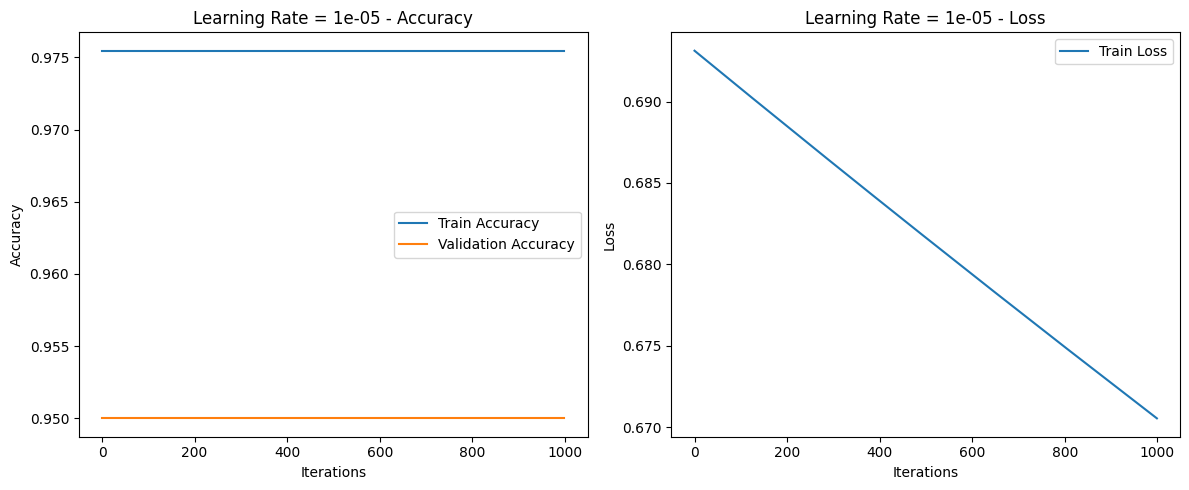

In [20]:
for lr in [0.1, 0.001, 0.00001]:
    model = LogisticRegression(learning_rate=lr, n_iterations=1000)
    model.fit(X_train_norm, y_train, X_val_norm, y_val)
    plot_learning_curves(model, f"Learning Rate = {lr}")


=== Q5: Batch Size Experiment ===
Batch Size: 4, Val Accuracy: 0.9429
Batch Size: 8, Val Accuracy: 0.9429
Batch Size: 16, Val Accuracy: 0.9429
Batch Size: 32, Val Accuracy: 0.9429
Batch Size: 64, Val Accuracy: 0.9429


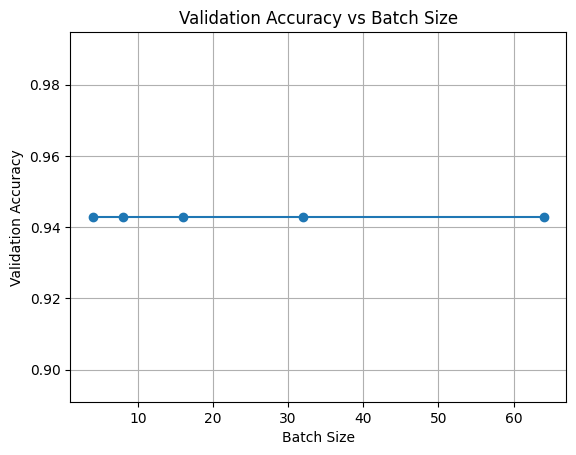

In [22]:
experiment_batch_sizes(X_train_norm, y_train, X_val_norm, y_val)


=== Q6: Regularization Experiment ===
Lambda: 0, Train Acc: 0.9714, Val Acc: 0.9500
Lambda: 0.001, Train Acc: 0.9714, Val Acc: 0.9500
Lambda: 0.01, Train Acc: 0.9714, Val Acc: 0.9429
Lambda: 0.1, Train Acc: 0.9407, Val Acc: 0.9500
Lambda: 1, Train Acc: 0.6544, Val Acc: 0.6571
Lambda: 10, Train Acc: 0.6544, Val Acc: 0.6571


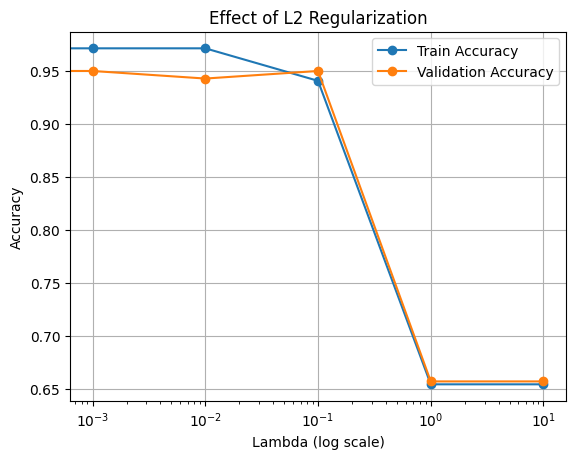

In [23]:
experiment_regularization(X_train_norm, y_train, X_val_norm, y_val)


=== Q7: Without Normalization ===

Training with LR=0.01 (Unnormalized)


<ipython-input-14-d8bf95558541>:14: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


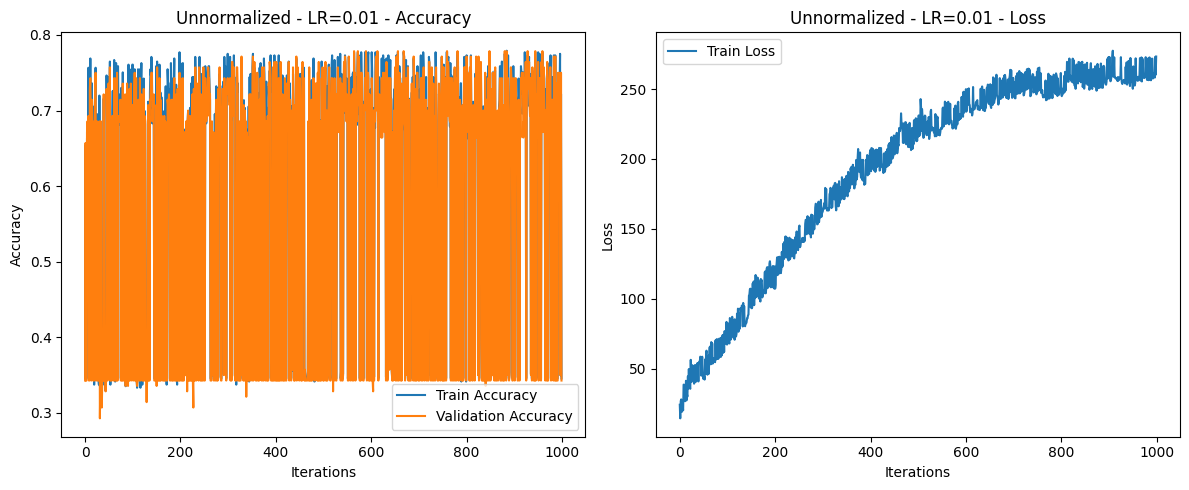


Training with LR=0.1 (Unnormalized)


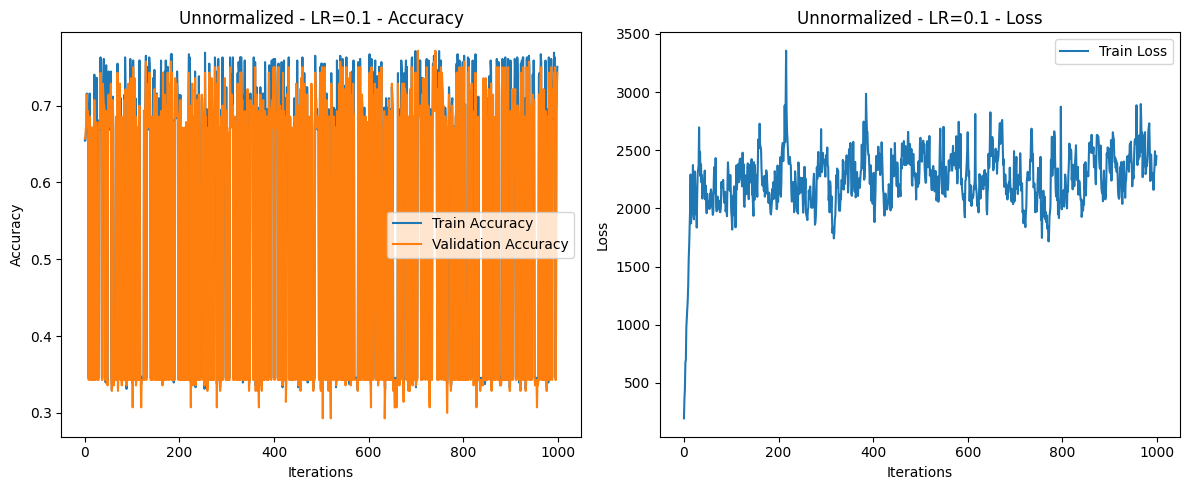


Training with LR=1e-05 (Unnormalized)


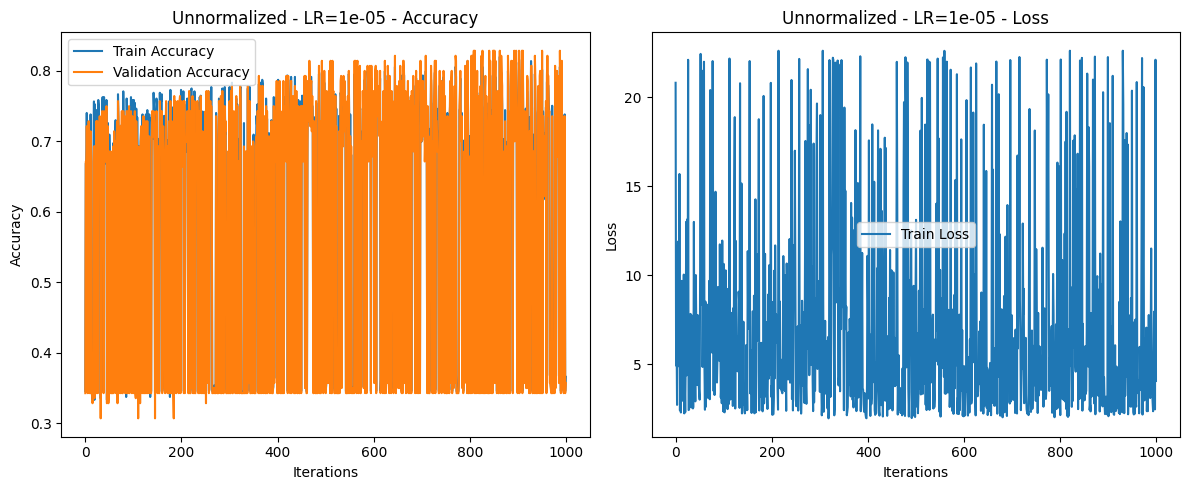


=== Q7: With Normalization ===

Training with LR=0.01 (Normalized)


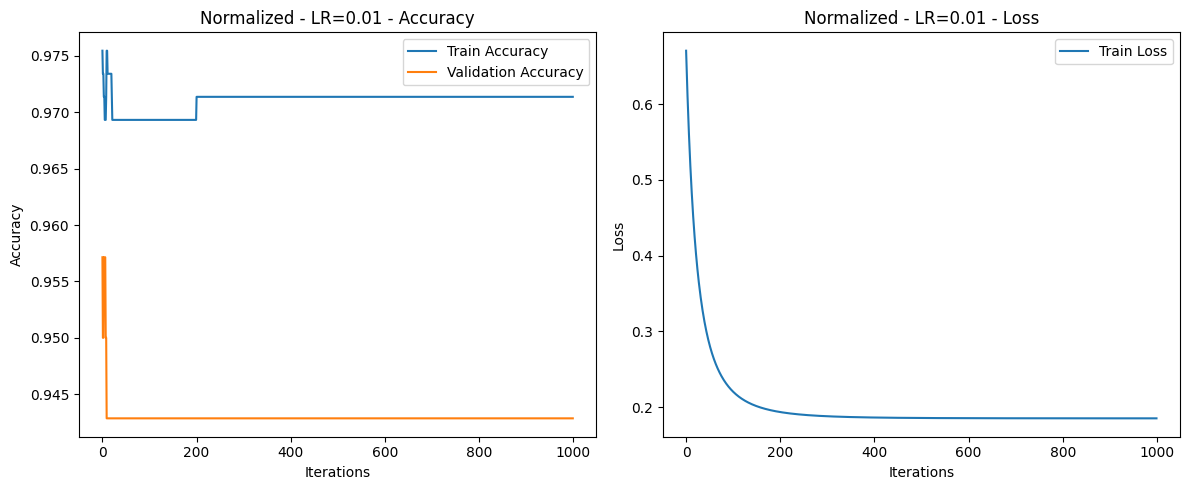


Training with LR=0.1 (Normalized)


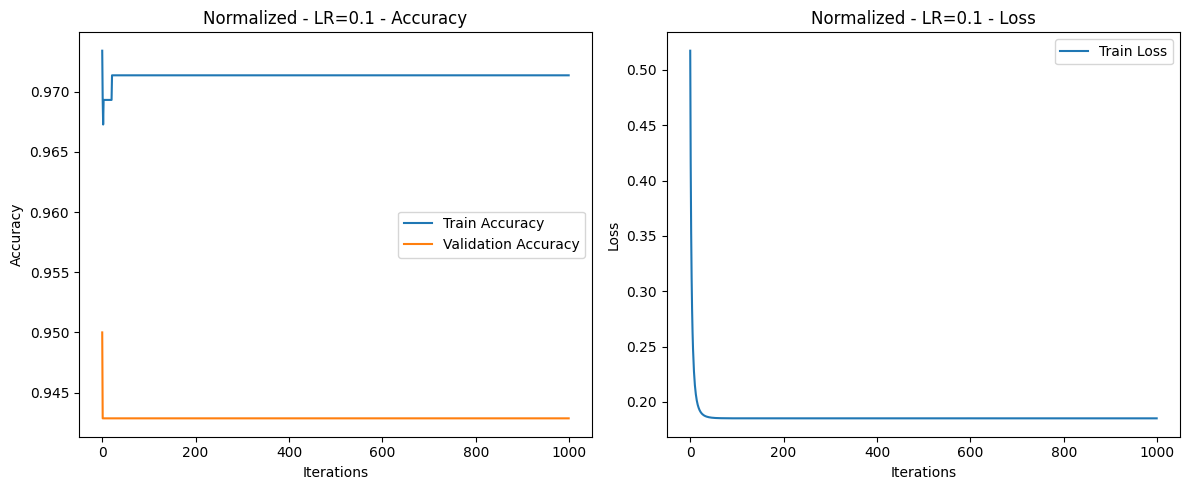


Training with LR=1e-05 (Normalized)


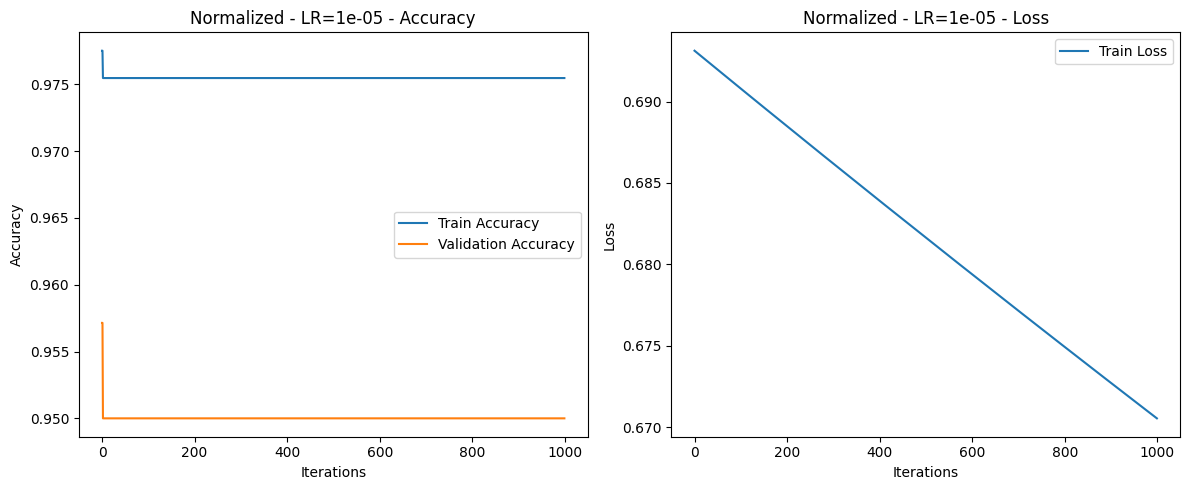

In [27]:
def experiment_with_normalization(X_train, y_train, X_val, y_val):
    learning_rates = [0.01, 0.1, 0.00001]

    print("\n=== Q7: Without Normalization ===")
    for lr in learning_rates:
        print(f"\nTraining with LR={lr} (Unnormalized)")
        model = LogisticRegression(learning_rate=lr, n_iterations=1000, batch_size=16)
        model.fit(X_train, y_train, X_val, y_val, verbose=False)
        plot_learning_curves(model, f"Unnormalized - LR={lr}")

    print("\n=== Q7: With Normalization ===")
    X_train_norm, X_val_norm, _ = min_max_normalize(X_train, X_val, X_val)
    for lr in learning_rates:
        print(f"\nTraining with LR={lr} (Normalized)")
        model = LogisticRegression(learning_rate=lr, n_iterations=1000, batch_size=16)
        model.fit(X_train_norm, y_train, X_val_norm, y_val, verbose=False)
        plot_learning_curves(model, f"Normalized - LR={lr}")
experiment_with_normalization(X_train, y_train, X_val, y_val)

In [28]:
print("\n=== Q8: Shuffling Experiment ===")
for i in range(3):
    model = LogisticRegression(learning_rate=0.01, n_iterations=1000)
    indices = np.random.permutation(len(X_train_norm))
    X_shuffled = X_train_norm[indices]
    y_shuffled = y_train[indices]
    model.fit(X_shuffled, y_shuffled, X_val_norm, y_val, verbose=False)
    val_acc = model.evaluate(X_val_norm, y_val)
    print(f"Run {i+1}: Validation Accuracy = {val_acc:.4f}")


=== Q8: Shuffling Experiment ===
Run 1: Validation Accuracy = 0.9429
Run 2: Validation Accuracy = 0.9429
Run 3: Validation Accuracy = 0.9429
